# SAM2: Segmentacion Universal de Imagenes

SAM2 (Segment Anything Model 2) es un modelo que puede segmentar cualquier objeto en una imagen sin entrenamiento previo.

**Que hace SAM2:**
- Segmenta objetos a nivel de pixel (mascaras precisas)
- Funciona con puntos o boxes como entrada
- No necesita saber que objeto es, solo lo segmenta
- Soporta video (seguimiento de objetos entre frames)

En este notebook veremos como usar SAM2 con la libreria `transformers` de Hugging Face.

## Configuracion e Imports

In [5]:
import torch
import transformers
from transformers import Sam2Processor, Sam2Model
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import warnings
warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch version: {torch.__version__}, usando: {device}")
print(f"transformers version: {transformers.__version__}")

torch version: 2.7.1+cu128, usando: cuda
transformers version: 4.57.1


## Carga de SAM2

Usamos `facebook/sam2.1-hiera-base-plus`. Si tienes mas memoria GPU, puedes usar `sam2.1-hiera-large`.

In [15]:
model_name = "facebook/sam2.1-hiera-base-plus"
model_name = "facebook/sam2.1-hiera-large"
model = Sam2Model.from_pretrained(model_name).to(device)
processor = Sam2Processor.from_pretrained(model_name)
print("SAM2 cargado")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/898M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

SAM2 cargado


## Carga de Imagenes de Ejemplo

Imagenes cargadas


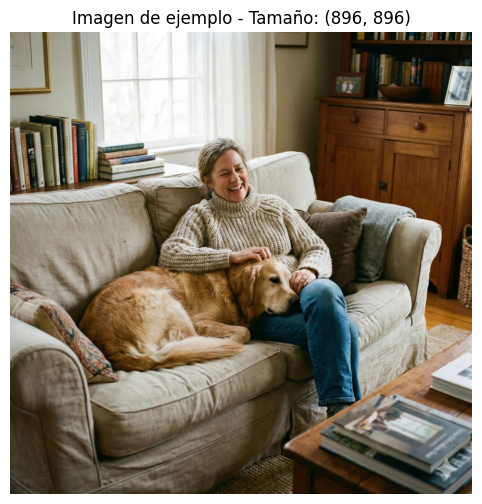

In [27]:
# Cargar imagenes desde GitHub
url_cars = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/cars.jpg"
image_cars = Image.open(BytesIO(requests.get(url_cars).content)).convert("RGB")

url_person_dog = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/person_dog.jpg"
image_person_dog = Image.open(BytesIO(requests.get(url_person_dog).content)).convert("RGB")

url_dog = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/dog.jpg"
image_dog = Image.open(BytesIO(requests.get(url_dog).content)).convert("RGB")

url_dog2 = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/dog2.jpg"
image_dog2 = Image.open(BytesIO(requests.get(url_dog2).content)).convert("RGB")

url_fruits = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/fruits.jpg"
image_fruits = Image.open(BytesIO(requests.get(url_fruits).content)).convert("RGB")

url_fruits3 = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/fruits3.jpg"
image_fruits3 = Image.open(BytesIO(requests.get(url_fruits3).content)).convert("RGB")

url_bananas = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/bananas.jpg"
image_bananas = Image.open(BytesIO(requests.get(url_bananas).content)).convert("RGB")

url_person_banana = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/person_banana.jpg"
image_person_banana = Image.open(BytesIO(requests.get(url_person_banana).content)).convert("RGB")
print("Imagenes cargadas")

# Mostrar imagen
plt.figure(figsize=(10, 6))
plt.imshow(image_person_dog)
plt.title(f"Imagen de ejemplo - Tamaño: {image_person_dog.size}")
plt.axis("off")
plt.show()

## SAM2: Segmentacion con Puntos

SAM2 permite segmentar objetos usando puntos. El formato de entrada es:
- `input_points`: 4 dimensiones `[batch, num_objects, points_per_object, 2]`
- `input_labels`: 3 dimensiones `[batch, num_objects, points_per_object]` donde 1=positivo, 0=negativo

**Ejemplo**: Un click positivo en `(x, y)` se representa como `input_points=[[[[x, y]]]]` e `input_labels=[[[1]]]`

In [59]:
# Definir punto de entrada
# Formato: 4 dimensiones (batch, object, points_per_object, coordinates)
input_points = [[287, 537]]  # Click en en la persona

# Labels: 3 dimensiones (batch, object, point_label)
# 1 = click positivo, 0 = click negativo
input_labels = [1]

# Procesar con SAM2
inputs = processor(
    images=image_person_dog, 
    input_points=[[input_points]], 
    input_labels=[[input_labels]], 
    return_tensors="pt"
).to(device)

# Inferencia
with torch.no_grad():
    outputs = model(**inputs)

# Post-procesar mascaras (solo 2 argumentos)
masks = processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"]
)[0]

# SAM2 genera 3 mascaras con diferentes niveles de detalle
# Elegimos la mejor segun IoU score
scores = outputs.iou_scores[0, 0]
best_idx = scores.argmax().item()
best_mask = masks[0][best_idx].cpu().numpy()

print(f"Scores IoU de las 3 mascaras: {scores.cpu().numpy()}")
print(f"Mascara seleccionada: {best_idx} (score: {scores[best_idx]:.4f})")
print(f"Shape de la mascara: {best_mask.shape}")

Scores IoU de las 3 mascaras: [0.61388814 0.980996   0.9853349 ]
Mascara seleccionada: 2 (score: 0.9853)
Shape de la mascara: (896, 896)


## Visualizacion de Resultados

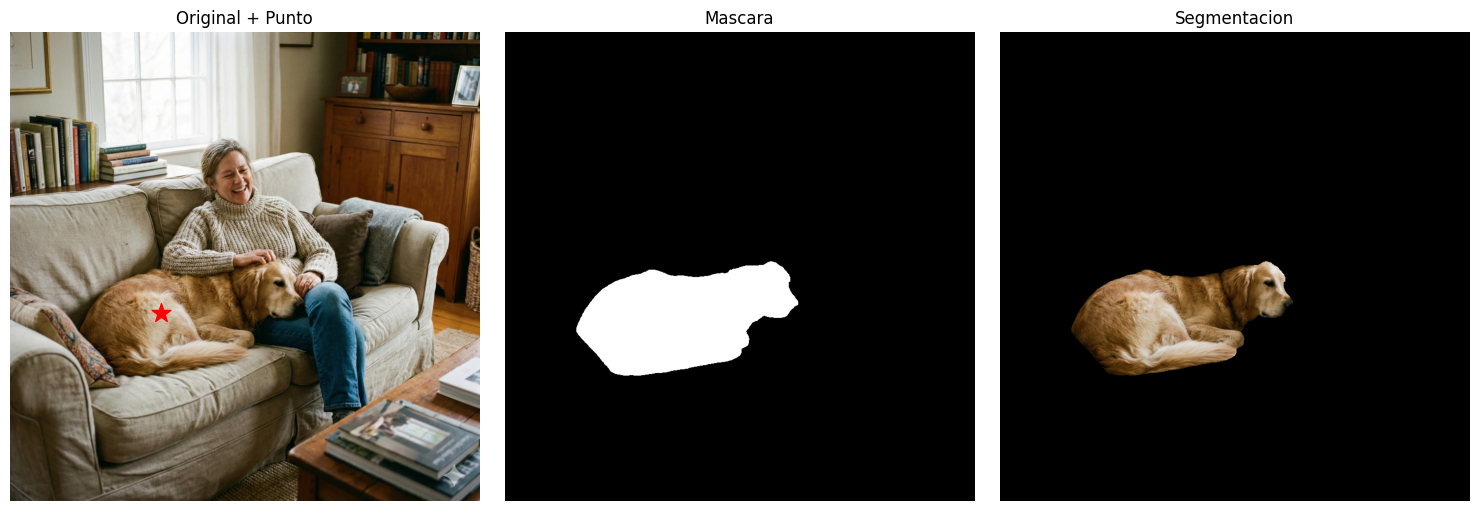

In [60]:
# Visualizar resultados
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Imagen original con punto
axes[0].imshow(image_person_dog)
axes[0].scatter([287], [537], c='red', s=200, marker='*')
axes[0].set_title("Original + Punto")
axes[0].axis("off")

# Mascara
axes[1].imshow(best_mask, cmap="gray")
axes[1].set_title("Mascara")
axes[1].axis("off")

# Resultado
masked_img = np.array(image_person_dog) * best_mask[:, :, None]
axes[2].imshow(masked_img.astype(np.uint8))
axes[2].set_title("Segmentacion")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Multiples Puntos

Podemos usar varios puntos para refinar la segmentacion. Puntos positivos (1) indican que pertenecen al objeto, puntos negativos (0) indican que NO pertenecen.

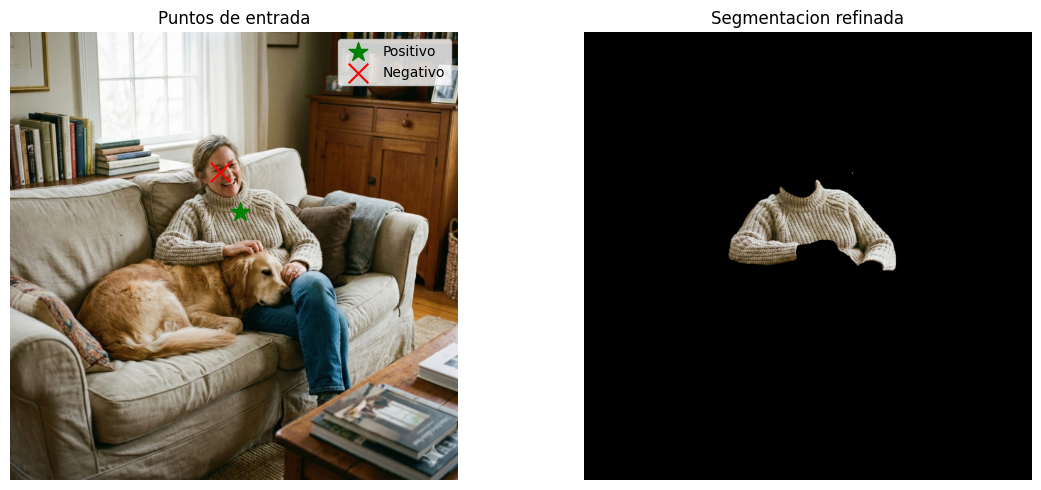

In [57]:
# Multiples puntos: 2 positivos en el camion, 1 negativo en el fondo


input_points = [[460, 360], [420, 280]]
input_labels = [1, 0]  # 1=positivo, 0=negativo

inputs = processor(
    images=image_person_dog, 
    input_points=[[input_points]], 
    input_labels=[[input_labels]], 
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-procesar mascaras (solo 2 argumentos)
masks = processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"]
)[0]

scores = outputs.iou_scores[0, 0]
best_idx = scores.argmax().item()
best_mask = masks[0][best_idx].cpu().numpy()

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image_person_dog)
# Puntos positivos en verde, negativos en rojo
axes[0].scatter(input_points[0][0], input_points[0][1], c='green', s=200, marker='*', label='Positivo')
axes[0].scatter(input_points[1][0], input_points[1][1], c='red', s=200, marker='x', label='Negativo')
axes[0].legend()
axes[0].set_title("Puntos de entrada")
axes[0].axis("off")

masked_img = np.array(image_person_dog) * best_mask[:, :, None]
axes[1].imshow(masked_img.astype(np.uint8))
axes[1].set_title("Segmentacion refinada")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Funcion Reutilizable

Creamos una funcion que encapsula todo el proceso de segmentacion.

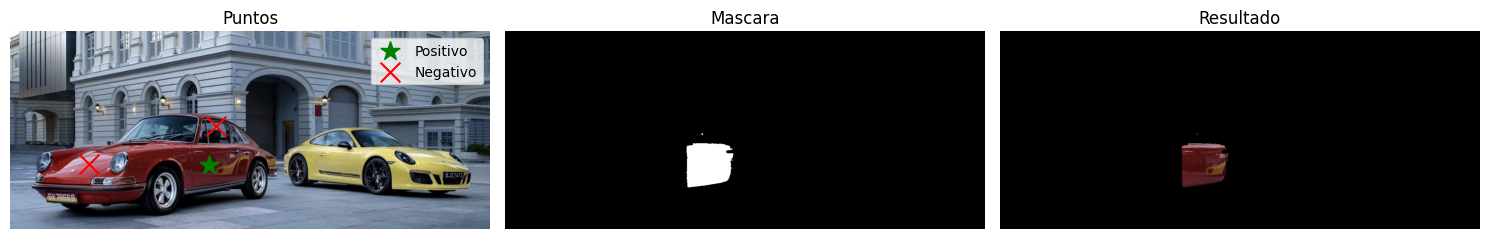

In [ ]:
def segment_with_sam2(image, points, labels, show=True):
    """Segmenta una imagen usando SAM2 con puntos.
    
    Args:
        image: Imagen PIL
        points: Lista de coordenadas [[x1, y1], [x2, y2], ...]
        labels: Lista de labels [1, 0, 1, ...] (1=positivo, 0=negativo)
        show: Si True, muestra visualizacion
    
    Returns:
        Mascara numpy array
    """
    # Formatear para SAM2 (4D points, 3D labels)
    input_points = [[[p for p in points]]]
    input_labels = [[labels]]
    
    inputs = processor(
        images=image, 
        input_points=input_points, 
        input_labels=input_labels, 
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Post-procesar mascaras (solo 2 argumentos)
    masks = processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"]
    )[0]
    
    scores = outputs.iou_scores[0, 0]
    best_idx = scores.argmax().item()
    best_mask = masks[0][best_idx].cpu().numpy()
    
    if show:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(image)
        pos_pts = [p for p, l in zip(points, labels) if l == 1]
        neg_pts = [p for p, l in zip(points, labels) if l == 0]
        if pos_pts:
            axes[0].scatter([p[0] for p in pos_pts], [p[1] for p in pos_pts], 
                           c='green', s=200, marker='*', label='Positivo')
        if neg_pts:
            axes[0].scatter([p[0] for p in neg_pts], [p[1] for p in neg_pts], 
                           c='red', s=200, marker='x', label='Negativo')
        axes[0].legend()
        axes[0].set_title("Puntos")
        axes[0].axis("off")
        
        axes[1].imshow(best_mask, cmap="gray")
        axes[1].set_title("Mascara")
        axes[1].axis("off")
        
        masked_img = np.array(image) * best_mask[:, :, None]
        axes[2].imshow(masked_img.astype(np.uint8))
        axes[2].set_title("Resultado")
        axes[2].axis("off")
        
        plt.tight_layout()
        plt.show()
    
    return best_mask

# Ejemplo de uso
# mask = segment_with_sam2(image_fruits3, [[1001, 878]], [1])



## Ejercicio opcional 1

Prueba segmentar diferentes partes de la imagen:

1. Segmenta solo la puerta del coche
2. Usa puntos negativos para excluir partes
3. Prueba con tu propia imagen

In [ ]:
# EJERCICIO: Tu codigo aqui

# Ejemplo 1: Segmentar el coche
# mask_coche = segment_with_sam2(image_cars, [[, ]], [1])

# Ejemplo 2: Segmentar con punto negativo
# mask_refined = segment_with_sam2(raw_image, [[, ], [, ]], [1, 0])

# Ejemplo 3: Tu propia imagen
# my_image = Image.open("tu_imagen.jpg").convert("RGB")
# mask = segment_with_sam2(my_image, [[x, y]], [1])

## Grounding DINO + SAM2

Combinamos Grounding DINO (deteccion por texto) con SAM2 (segmentacion):

1. **Grounding DINO** detecta objetos usando un prompt de texto y genera bounding boxes
2. **SAM2** toma esas boxes y genera mascaras precisas a nivel de pixel

**Formato de boxes para SAM2**: `input_boxes=[[[x1, y1, x2, y2]]]` con 3 dimensiones (batch, num_boxes, coordinates)

Detectados 4 objetos: ['red car', '', '', '']


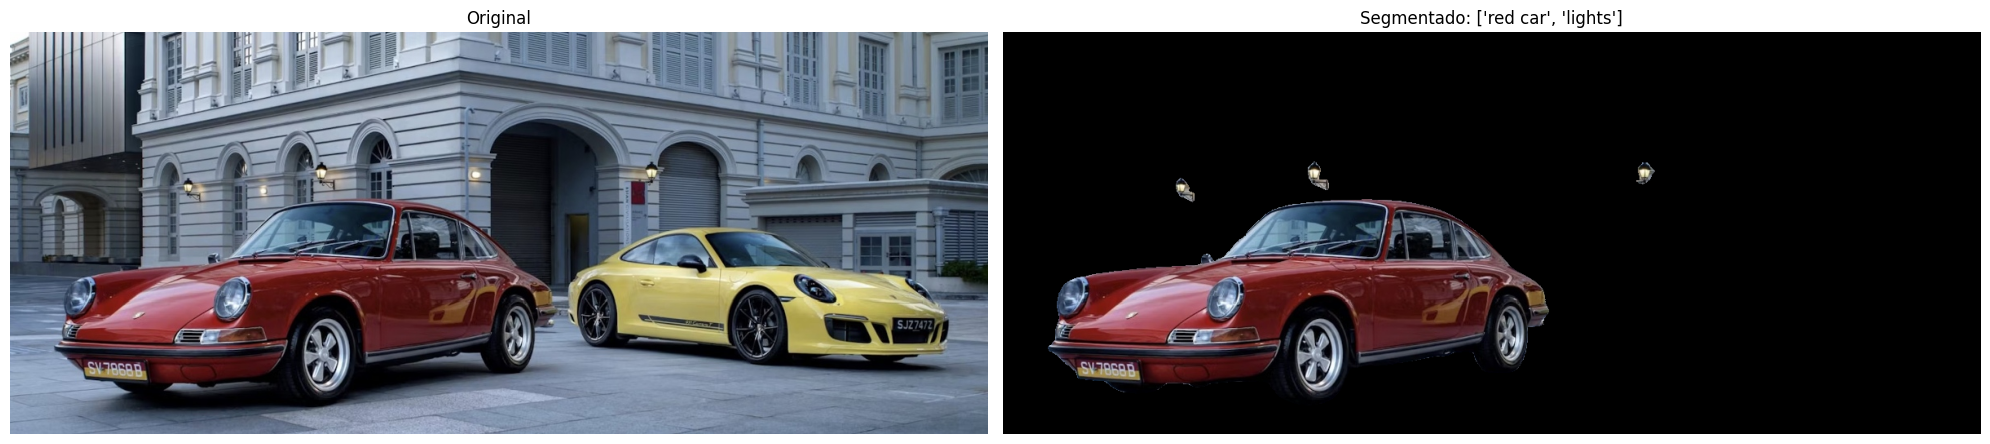

In [56]:
# Grounding DINO + SAM2
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

dino_path = "IDEA-Research/grounding-dino-base"
dino_processor = AutoProcessor.from_pretrained(dino_path)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(dino_path).to(device)


def segment_objects(image, prompt, box_threshold=0.5, text_threshold=0.6):
    """Segmenta objetos usando Grounding DINO + SAM2"""
    w, h = image.size
    
    # 1. Detectar con Grounding DINO
    inputs = dino_processor(images=image, text=prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = dino_model(**inputs)
    
    results = dino_processor.post_process_grounded_object_detection(
        outputs, 
        inputs.input_ids, 
        threshold=box_threshold, 
        text_threshold=text_threshold, 
        target_sizes=[(h, w)]
    )
    
    boxes = results[0]['boxes'].cpu().numpy().tolist()
    labels = results[0]['labels']
    print(f"Detectados {len(boxes)} objetos: {labels}")
    
    if len(boxes) == 0:
        print("No se detectaron objetos")
        return None
    
    # 2. Segmentar cada box con SAM2
    final_mask = np.zeros((h, w), dtype=np.float32)
    
    for box in boxes:
        # Formato SAM2: input_boxes=[[[x1, y1, x2, y2]]]
        sam_inputs = processor(
            images=image, 
            input_boxes=[[box]], 
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            sam_outputs = model(**sam_inputs)
        
        # Post-process con solo 2 argumentos
        masks = processor.post_process_masks(
            sam_outputs.pred_masks.cpu(),
            sam_inputs["original_sizes"]
        )[0]
        
        # Mejor mascara segun IoU
        scores = sam_outputs.iou_scores[0, 0]
        best_idx = scores.argmax().item()
        best_mask = masks[0][best_idx].cpu().numpy()
        final_mask += best_mask
    
    final_mask = np.clip(final_mask, 0, 1)
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    masked_img = np.array(image) * final_mask[:, :, None]
    axes[1].imshow(masked_img.astype(np.uint8))
    axes[1].set_title(f"Segmentado: {prompt}")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    return final_mask

# Ejemplo
mask = segment_objects(image_cars, ["red car", "lights"])

## Resumen

En este notebook hemos aprendido:

- Que es SAM2 y como funciona la segmentacion universal  
- Cargar SAM2 con `Sam2Processor` y `Sam2Model` de transformers
- Segmentar objetos con un solo punto (click positivo)
- Refinar segmentaciones con multiples puntos (positivos y negativos)
- Crear una funcion reutilizable para segmentacion
- Combinar SAM2 con Grounding DINO para segmentar objetos en una imagen

**Modelo usado**: `facebook/sam2.1-hiera-base-plus`

**Formato de entrada**:
- `input_points`: 4 dimensiones `[batch, num_objects, points_per_object, 2]`
- `input_labels`: 3 dimensiones `[batch, num_objects, points_per_object]`